# Experiment 7 — ensemble diversity and complementary models

**Question / hypothesis.** Can a meaningfully different tree family improve the highly optimized E6 LightGBM/XGBoost ranking by contributing complementary errors?

**Held constant.** The Experiment 4 feature set, exact five stratified folds, E6 component predictions, and E6's internal 40/60 ratio remain fixed. No leaderboard feedback enters selection.

**Changed.** Two adjacent lower-rate CatBoost configurations and one ExtraTrees configuration are evaluated. Candidate weight varies only from 0% to 30% in 5-point increments.

The notebook reads compact saved reports by default. Full OOF arrays and bootstrap draws remain ignored local artifacts; no model is trained during normal notebook review.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
REPORTS = ROOT / "reports"

models = pd.read_csv(REPORTS / "diversity_model_results.csv")
diversity = pd.read_csv(REPORTS / "diversity_correlations.csv")
blends = pd.read_csv(REPORTS / "diversity_blend_results.csv")
analysis = json.loads((REPORTS / "diversity_analysis.json").read_text())
print("Loaded compact Experiment 7 reports")

Matplotlib is building the font cache; this may take a moment.


Loaded compact Experiment 7 reports


## E6 reconstruction

The ignored local E6 OOF file was reused and validated against the current target order. This avoids retraining either champion component.

In [2]:
e6 = pd.DataFrame([analysis["e6_reconstruction"]])
display(e6.style.format({
    "lightgbm_oof_auc": "{:.6f}", "xgboost_oof_auc": "{:.6f}",
    "blend_oof_auc": "{:.6f}", "lightgbm_weight": "{:.1f}", "xgboost_weight": "{:.1f}",
}))

,lightgbm_oof_auc,xgboost_oof_auc,blend_oof_auc,lightgbm_weight,xgboost_weight
0,0.963424,0.963991,0.964289,0.4,0.6


## Standalone candidates

CatBoost uses its categorical features natively and fold-local early stopping. ExtraTrees uses fold-local median/mode preprocessing and ordinal categorical encoding. Standalone AUC is secondary, but it establishes whether diversity is accompanied by enough predictive strength to help an ensemble.

,family,candidate,oof_auc,log_loss,mean_fold_auc,std_fold_auc,fit_seconds,predict_seconds,median_best_iteration,fold_1_auc,fold_2_auc,fold_3_auc,fold_4_auc,fold_5_auc
0,CatBoost,catboost_depth6_lr003,0.960203,0.232327,0.960204,0.000560,936.4,0.5,2500,0.959453,0.960088,0.960324,0.961015,0.960141
1,CatBoost,catboost_depth7_lr003,0.961239,0.229201,0.961240,0.000556,1056.9,0.5,2500,0.960586,0.961011,0.961304,0.962106,0.961195
2,ExtraTrees,extra_trees_sqrt_leaf2,0.939021,0.284852,0.939024,0.000745,95.3,11.3,—,0.938246,0.938370,0.939350,0.940062,0.939091


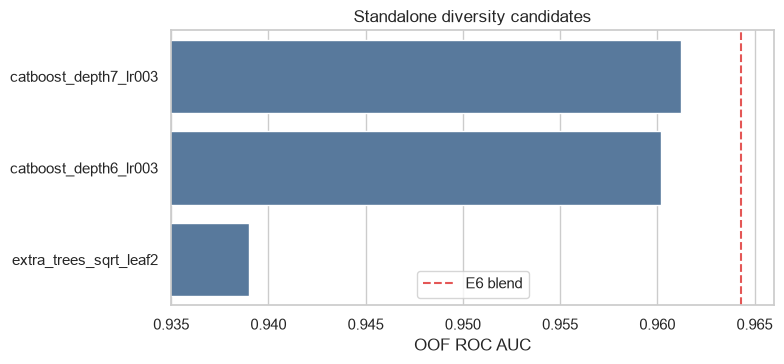

In [3]:
summary_columns = [
    "family", "candidate", "oof_auc", "log_loss", "mean_fold_auc", "std_fold_auc",
    "fit_seconds", "predict_seconds", "median_best_iteration",
] + [f"fold_{fold}_auc" for fold in range(1, 6)]
display(models[summary_columns].style.format({
    "oof_auc": "{:.6f}", "log_loss": "{:.6f}", "mean_fold_auc": "{:.6f}",
    "std_fold_auc": "{:.6f}", "fit_seconds": "{:.1f}", "predict_seconds": "{:.1f}",
    "median_best_iteration": "{:.0f}", **{f"fold_{fold}_auc": "{:.6f}" for fold in range(1, 6)},
}, na_rep="—"))

fig, ax = plt.subplots(figsize=(8, 3.8))
sns.barplot(data=models.sort_values("oof_auc", ascending=False), x="oof_auc", y="candidate", color="#4C78A8", ax=ax)
ax.axvline(analysis["e6_reconstruction"]["blend_oof_auc"], color="#E45756", linestyle="--", label="E6 blend")
ax.set_xlim(0.935, 0.966)
ax.set(title="Standalone diversity candidates", xlabel="OOF ROC AUC", ylabel="")
ax.legend()
plt.tight_layout()
plt.show()

Depth 7 improves CatBoost over depth 6, but both use all 2,500 allowed iterations on every fold, so validation did not converge before the cap. ExtraTrees is roughly ten times faster than CatBoost CV but is materially weaker. These are useful diversity candidates only if their errors improve E6 conditionally.

## Prediction diversity and conditional behavior

Lower correlation and greater disagreement do not automatically imply complementarity. The diagnostics below also compare which model is correct at threshold 0.5 and performance on the 10% of rows with the largest probability differences. That subset is prediction-selected, so its metrics are descriptive rather than an unbiased performance estimate.

In [4]:
diversity_columns = [
    "candidate", "pearson_vs_e6", "spearman_vs_e6",
    "mean_absolute_probability_difference", "threshold_disagreement",
    "threshold_disagreement_y0", "threshold_disagreement_y1",
    "substantial_subset_e6_auc", "substantial_subset_candidate_auc",
    "candidate_correct_e6_wrong_rate", "e6_correct_candidate_wrong_rate",
    "candidate_net_threshold_corrections",
]
display(diversity[diversity_columns].style.format({
    "pearson_vs_e6": "{:.6f}", "spearman_vs_e6": "{:.6f}",
    "mean_absolute_probability_difference": "{:.4f}", "threshold_disagreement": "{:.2%}",
    "threshold_disagreement_y0": "{:.2%}", "threshold_disagreement_y1": "{:.2%}",
    "substantial_subset_e6_auc": "{:.6f}", "substantial_subset_candidate_auc": "{:.6f}",
    "candidate_correct_e6_wrong_rate": "{:.2%}", "e6_correct_candidate_wrong_rate": "{:.2%}",
}))

,candidate,pearson_vs_e6,spearman_vs_e6,mean_absolute_probability_difference,threshold_disagreement,threshold_disagreement_y0,threshold_disagreement_y1,substantial_subset_e6_auc,substantial_subset_candidate_auc,candidate_correct_e6_wrong_rate,e6_correct_candidate_wrong_rate,candidate_net_threshold_corrections
0,catboost_depth6_lr003,0.986467,0.985685,0.0341,3.20%,5.56%,2.24%,0.833797,0.766570,1.29%,1.91%,-4256
1,catboost_depth7_lr003,0.988828,0.987396,0.0306,2.88%,4.98%,2.02%,0.822779,0.771551,1.22%,1.66%,-3065
2,extra_trees_sqrt_leaf2,0.926318,0.958605,0.0864,8.76%,15.85%,5.85%,0.906390,0.545148,2.53%,6.23%,-25633


All candidates disagree more often for true negatives. ExtraTrees is the most different, but on high-difference rows it trails E6 sharply and creates far more threshold errors than it corrects. CatBoost is closer to E6 and less harmful, yet still has negative net threshold corrections. The evidence points primarily to noise rather than systematic correction of E6 errors.

## Conditional ensemble contribution

Every curve preserves the 40/60 LightGBM/XGBoost ratio inside the remaining E6 weight. A robust addition should improve across neighboring weights rather than at one selected point.

,candidate,candidate_weight,e6_weight,oof_auc,log_loss,delta_vs_e6
0,catboost_depth6_lr003,0%,100%,0.964289,0.218659,+0.000000
1,catboost_depth6_lr003,5%,95%,0.964272,0.218792,-0.000018
2,catboost_depth6_lr003,10%,90%,0.964233,0.219019,-0.000056
3,catboost_depth6_lr003,15%,85%,0.964176,0.219319,-0.000113
4,catboost_depth6_lr003,20%,80%,0.964101,0.219683,-0.000188
5,catboost_depth6_lr003,25%,75%,0.964009,0.220107,-0.000280
6,catboost_depth6_lr003,30%,70%,0.963899,0.220585,-0.000391
7,catboost_depth7_lr003,0%,100%,0.964289,0.218659,+0.000000
8,catboost_depth7_lr003,5%,95%,0.964292,0.218720,+0.000002
9,catboost_depth7_lr003,10%,90%,0.964276,0.218859,-0.000013


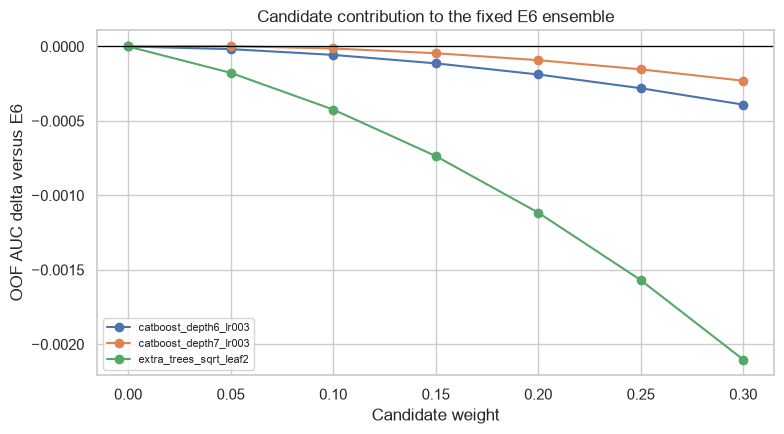

In [5]:
display(blends[["candidate", "candidate_weight", "e6_weight", "oof_auc", "log_loss", "delta_vs_e6"]]
        .style.format({"candidate_weight": "{:.0%}", "e6_weight": "{:.0%}", "oof_auc": "{:.6f}", "log_loss": "{:.6f}", "delta_vs_e6": "{:+.6f}"}))

fig, ax = plt.subplots(figsize=(8, 4.5))
for candidate, group in blends.groupby("candidate", sort=False):
    ax.plot(group["candidate_weight"], group["delta_vs_e6"], marker="o", label=candidate)
ax.axhline(0, color="black", linewidth=0.9)
ax.set(title="Candidate contribution to the fixed E6 ensemble", xlabel="Candidate weight", ylabel="OOF AUC delta versus E6")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

Depth-6 CatBoost and ExtraTrees degrade E6 at every non-zero weight. Depth-7 CatBoost is +0.000002 at 5%, then negative from 10% onward. This isolated result has no neighboring support, so no multi-candidate ensemble is warranted.

## Paired uncertainty and decision

The numerical-best 5% depth-7 CatBoost blend was bootstrapped despite failing the broad-neighborhood rule. Because the configuration and weight were selected on the same OOF predictions, this interval addresses sampling variability but not ensemble-selection bias.

In [6]:
bootstrap = analysis["paired_bootstrap_vs_e6"]
decision = pd.DataFrame([{
    "proposed_ensemble": "95% E6 + 5% depth-7 CatBoost",
    "oof_auc": analysis["best_proposed_ensemble"]["oof_auc"],
    "observed_gain": analysis["observed_delta_vs_e6"],
    "bootstrap_mean_gain": bootstrap["mean"],
    "ci_95_lower": bootstrap["ci_95_lower"],
    "ci_95_upper": bootstrap["ci_95_upper"],
    "positive_resamples": bootstrap["proportion_positive"],
    "submission_recommended": analysis["submission_recommended_by_statistical_rules"],
}])
display(decision.style.format({
    "oof_auc": "{:.6f}", "observed_gain": "{:+.8f}", "bootstrap_mean_gain": "{:+.8f}",
    "ci_95_lower": "{:+.8f}", "ci_95_upper": "{:+.8f}", "positive_resamples": "{:.1%}",
}))

,proposed_ensemble,oof_auc,observed_gain,bootstrap_mean_gain,ci_95_lower,ci_95_upper,positive_resamples,submission_recommended
0,95% E6 + 5% depth-7 CatBoost,0.964292,+0.00000233,+0.00000222,-0.00000287,+0.00000782,76.4%,False


## Conclusion

The experiment finds diversity, but not useful complementary ranking information. ExtraTrees produces the largest prediction differences and the worst blend curve. Depth-7 CatBoost is stronger and less correlated with E6 than its components are with each other, but its only positive weight is an isolated 5% point with a negligible +0.000002 AUC gain; the paired 95% interval crosses zero and only 76.4% of resamples are positive.

**Not promoted:** E6 remains champion at **0.964289 OOF AUC**. No Experiment 7 submission is created. The negative result is valuable: adding structural diversity requires conditional accuracy, not merely lower correlation or more threshold disagreement.